# The Cost Function of Logistic Regression

> 📖 Book: [ch06](../../.claude/skills/ml-knowledge/chapters/ch06-logistic-regression.md) · Prev: [01](01_hypothesis_and_activations.ipynb) · Next: [03 Decision boundary](03_decision_boundary.ipynb)

## Why not squared error?

With a sigmoid hypothesis, the squared-error cost $\frac{1}{2m}\sum(h_\theta(x^{(i)}) - y^{(i)})^2$ is **not convex**. That's bad news: gradient descent can easily fail on non-convex landscapes.

A function is convex if its second derivative is non-negative everywhere. The issue is not a negative second derivative per se (if it's negative everywhere, $-J$ is convex and we look for a maximum); the issue is a second derivative that changes sign, i.e. **inflection points**, flat plateaus and possibly local minima.

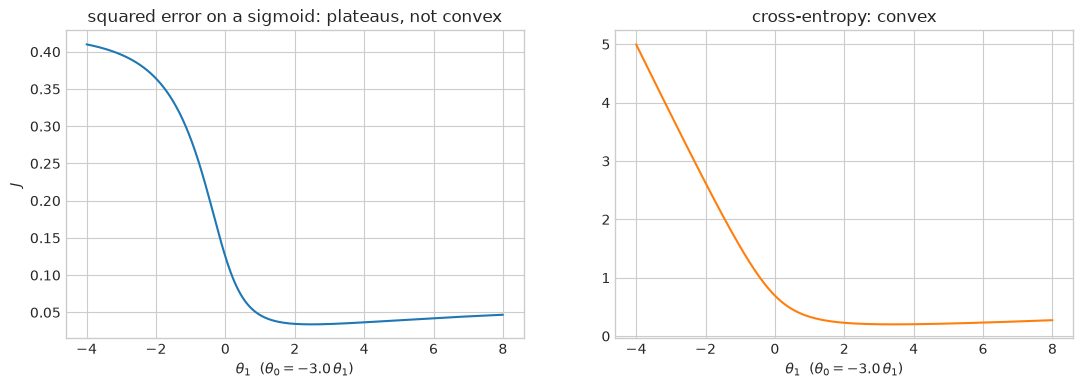

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.linear_models import add_bias
from ml.logistic import cross_entropy_cost, cross_entropy_gradient, fit_logistic, sigmoid
from ml.visualization.plots import plot_convergence

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

x = np.r_[rng.normal(2, 1.0, 30), rng.normal(4, 1.0, 30)]  # overlapping classes
y = np.r_[np.zeros(30), np.ones(30)]
X = add_bias(x)

# Cost along theta_1 (theta_0 fixed at the optimum ratio) for both costs
t1 = np.linspace(-4, 8, 400)
sq = [np.mean((sigmoid(X @ np.array([-3.0 * t, t])) - y) ** 2) / 2 for t in t1]
ce = [cross_entropy_cost(np.array([-3.0 * t, t]), X, y) for t in t1]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(t1, sq)
ax[0].set(title="squared error on a sigmoid: plateaus, not convex", xlabel=r"$\theta_1$  ($\theta_0 = -3.0\,\theta_1$)", ylabel=r"$J$")
ax[1].plot(t1, ce, "C1")
ax[1].set(title="cross-entropy: convex", xlabel=r"$\theta_1$  ($\theta_0 = -3.0\,\theta_1$)")
plt.show()

## A convex cost from maximum likelihood

We need a little statistics. Suppose logistic regression distinguishes cats ($y = 1$) from dogs ($y = 0$). The hypothesis for a sample $x^{(i)}$ is

$$
h_\theta(x^{(i)}) = p(y^{(i)} = \text{cat} \mid x^{(i)}, \theta) = \frac{1}{1 + e^{-x^{(i)}\theta}},
\qquad p(y^{(i)} = \text{dog} \mid x^{(i)}, \theta) = 1 - h_\theta(x^{(i)}).
$$

Both can be combined into one expression, a **Bernoulli trial**:

$$
p(y^{(i)} \mid x^{(i)}, \theta) = h_\theta(x^{(i)})^{y^{(i)}}\left(1 - h_\theta(x^{(i)})\right)^{1 - y^{(i)}} .
$$

(For $y^{(i)} = 1$ it gives $h_\theta$, for $y^{(i)} = 0$ it gives $1 - h_\theta$.)

Assuming independent samples, the joint probability of the whole training set is the product, the **likelihood**:

$$
\mathcal{L}(\theta) = p(Y \mid X, \theta) = \prod_{i=1}^m h_\theta(x^{(i)})^{y^{(i)}}\left(1 - h_\theta(x^{(i)})\right)^{1 - y^{(i)}} .
$$

We want to **maximize** it. The product is inconvenient to differentiate; since $\log$ is monotonic, the maximizer of $\log\mathcal{L}$ is the same, and the log turns the product into a sum:

$$
\log\mathcal{L}(\theta) = \sum_{i=1}^m y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log\left(1 - h_\theta(x^{(i)})\right).
$$

Flip the sign to get a minimization problem (the max of $f$ is the min of $-f$) and divide by $m$ (doesn't move the optimum). The **cross-entropy** (log-loss) cost is

$$
\boxed{J(\theta) = -\frac1m\sum_{i=1}^m \left[y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log\left(1 - h_\theta(x^{(i)})\right)\right]}
$$

and, vectorized with $h = S(X\theta)$,

$$
J(\theta) = \frac1m\left(-y^T\log h - (1 - y)^T\log(1 - h)\right).
$$

Per sample, it is

$$
\mathrm{cost}(h_\theta(x), y) = \begin{cases} -\log h_\theta(x) & y = 1 \\ -\log\left(1 - h_\theta(x)\right) & y = 0 \end{cases}
$$

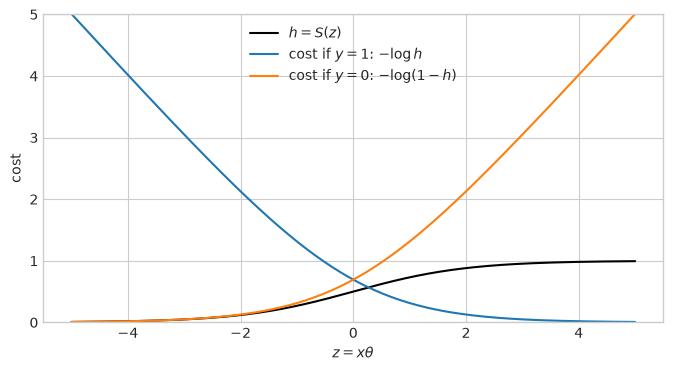

In [2]:
z = np.linspace(-5, 5, 200)
h = sigmoid(z)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, h, "k", label=r"$h = S(z)$")
ax.plot(z, -np.log(h), label=r"cost if $y = 1$: $-\log h$")
ax.plot(z, -np.log(1 - h), label=r"cost if $y = 0$: $-\log(1-h)$")
ax.set(xlabel=r"$z = x\theta$", ylabel="cost", ylim=(0, 5))
ax.legend()
plt.show()

- For $y = 1$: if $z \gg 0$ the hypothesis is right ($h \approx 1$) and the cost is $\approx 0$; if $z \ll 0$ it is confidently wrong and the cost $\to \infty$.
- For $y = 0$: the mirror image.

A confident wrong answer is punished very hard; that is exactly the behavior we want.

## Gradient of $J(\theta)$

Take one term of the sum, using $h_\theta(x^{(i)}) = S(x^{(i)}\theta)$ and $S' = S(1 - S)$:

$$
\begin{aligned}
\frac{\partial}{\partial\theta_j}\, y^{(i)}\log S(x^{(i)}\theta)
&= y^{(i)}\frac{1}{S(x^{(i)}\theta)}S(x^{(i)}\theta)\left(1 - S(x^{(i)}\theta)\right)x_j^{(i)}
= y^{(i)}\left(1 - S(x^{(i)}\theta)\right)x_j^{(i)}, \\
\frac{\partial}{\partial\theta_j}\,(1 - y^{(i)})\log\left(1 - S(x^{(i)}\theta)\right)
&= -(1 - y^{(i)})\frac{1}{1 - S(x^{(i)}\theta)}S(x^{(i)}\theta)\left(1 - S(x^{(i)}\theta)\right)x_j^{(i)}
= (y^{(i)} - 1)S(x^{(i)}\theta)\,x_j^{(i)} .
\end{aligned}
$$

Adding both:

$$
\left[y^{(i)} - y^{(i)}S + y^{(i)}S - S\right]x_j^{(i)} = \left[y^{(i)} - S(x^{(i)}\theta)\right]x_j^{(i)} .
$$

Restoring the sum and the $-\frac1m$:

$$
\boxed{\frac{\partial J}{\partial\theta_j} = \frac1m\sum_{i=1}^m\left[S(x^{(i)}\theta) - y^{(i)}\right]x_j^{(i)}}
\qquad\Longleftrightarrow\qquad
\nabla J = \frac1m X^T\left(S(X\theta) - y\right).
$$

This has **the same form as the gradient of linear regression**, although the objective is entirely different. So the same gradient descent applies:

$$
\theta := \theta - \frac\alpha m X^T\left(S(X\theta) - y\right) \quad \text{(simultaneous update)}.
$$

Let's verify the formula numerically (always do a gradient check when you implement a gradient by hand!) and then fit.

In [3]:
theta = rng.normal(size=2)
eps = 1e-6
numeric = np.array([(cross_entropy_cost(theta + eps * e, X, y) - cross_entropy_cost(theta - eps * e, X, y)) / (2 * eps) for e in np.eye(2)])
print("analytic :", cross_entropy_gradient(theta, X, y))
print("numerical:", numeric)

analytic : [-0.45011237 -2.0708923 ]
numerical: [-0.45011237 -2.0708923 ]


theta = [-10.218   3.434] -> decision boundary at x = 2.976


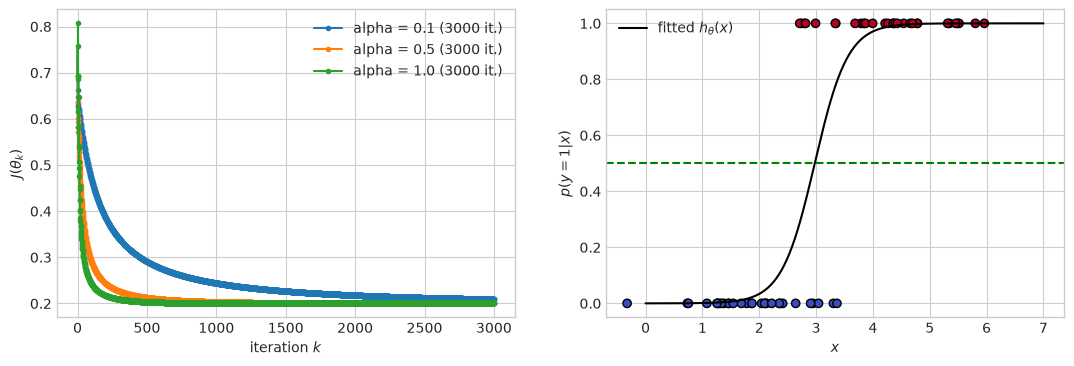

In [4]:
runs = {f"alpha = {a}": fit_logistic(X, y, alpha=a, max_iter=3000)[1] for a in (0.1, 0.5, 1.0)}
theta_hat = runs["alpha = 1.0"][-1, :2]
print("theta =", theta_hat.round(3), "-> decision boundary at x =", round(-theta_hat[0] / theta_hat[1], 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_convergence(runs, ax=ax[0], log=False)
xs = np.linspace(0, 7, 300)
ax[1].scatter(x, y, c=y, cmap="coolwarm", edgecolors="k")
ax[1].plot(xs, sigmoid(add_bias(xs) @ theta_hat), "k", label=r"fitted $h_\theta(x)$")
ax[1].axhline(0.5, c="g", ls="--")
ax[1].set(xlabel="$x$", ylabel=r"$p(y=1|x)$")
ax[1].legend()
plt.show()

⚠️ If the classes were **perfectly separable**, the likelihood could always be increased by scaling $\theta$ up (making the sigmoid steeper), so the unregularized optimum is at $\|\theta\| \to \infty$ and different optimizers stop at different places. Regularization ($\lambda > 0$) fixes that.

## Advanced optimization

Conjugate gradient, BFGS and L-BFGS are faster than gradient descent and need no $\alpha$. We only supply $J(\theta)$ and $\nabla J(\theta)$ to a library such as `scipy.optimize.minimize`. This is also what scikit-learn's `LogisticRegression` does internally (with L2 regularization by default: $C = 1/\lambda$).

In [5]:
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

res = minimize(cross_entropy_cost, np.zeros(2), args=(X, y), jac=cross_entropy_gradient, method="BFGS")
sk = LogisticRegression(C=1e10).fit(x[:, None], y)  # huge C = no regularization
print(f"BFGS    : theta = {res.x.round(3)} in {res.nit} iterations")
print(f"sklearn : theta = {np.r_[sk.intercept_, sk.coef_.ravel()].round(3)}")
print(f"GD      : theta = {theta_hat.round(3)} in {len(runs['alpha = 1.0']) - 1} iterations")

BFGS    : theta = [-10.244   3.442] in 15 iterations
sklearn : theta = [-10.229   3.437]
GD      : theta = [-10.218   3.434] in 3000 iterations


## Summary

- The squared-error cost of linear regression can't be reused: with a sigmoid it's non-convex.
- Maximum likelihood + log gives the convex cross-entropy cost.
- For the sigmoid, $\nabla J = \frac1m X^T(h - y)$: same shape as linear regression, so the same optimizers work.
- Regularized version: $J + \frac{\lambda}{2m}\sum_{j\ge1}\theta_j^2$ (implemented via `lam=` in `ml.logistic`).